# Simulating multiple casks

For a more complicated simulation, we can include multiple casks of SNF and look at the combined spectrum.

For example, we could assume 40 casks of SNF from the Sizewell reactor, with the following removal times:
* 10 casks removed 0.5 years ago
* 10 casks removed 5 years ago
* 10 casks removed 10 years ago
* 10 casks removed 20 years ago

Each cask has a mass of 10 tonnes.

To simplify the simulation, instead of simulating 10 individual 10-tonne casks for each removal time, we can just simulate one 100-tonne cask at each time.

As we're also assuming the isotopic proportions are the same for each cask, we can just create a single 100-tonne `Cask` object for the Sizewell reactor and then calculate the spectrum for each removal time.

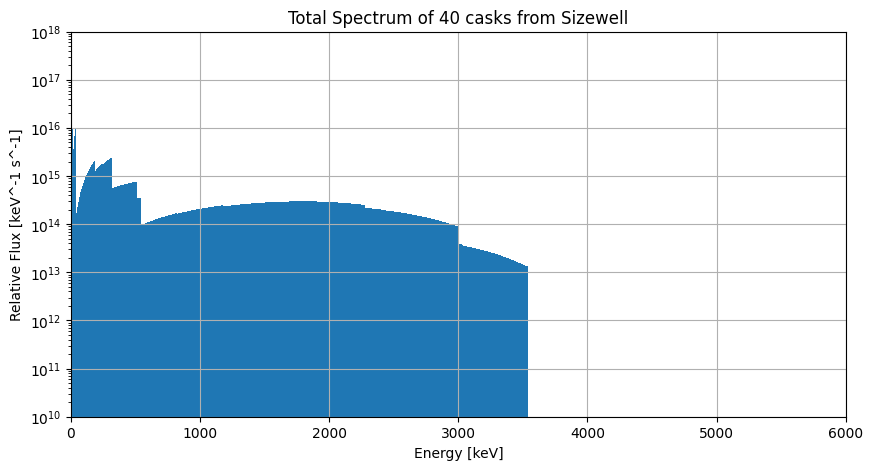

In [1]:
from snf_simulations.cask import Cask
import matplotlib.pyplot as plt
import numpy as np

reactor = "sizewell"
mass = 10000  # 10 tonnes
cask = Cask.from_reactor(reactor, total_mass=mass)
removal_times = [0.5, 5, 10, 20]

spectra = []
for removal_time in removal_times:
    total_spec = cask.get_total_spectrum(removal_time=removal_time)
    spectra.append(total_spec)

# Now combine all the spectra into one by adding them together
spec_multiple = spectra[0]
for spec in spectra[1:]:
    spec_multiple = spec_multiple + spec

# Plot the spectrum
figure = plt.figure(figsize=(10, 5))
axes = figure.add_subplot(1, 1, 1)

axes.bar(
    x=spec_multiple.energy[:-1],
    height=spec_multiple.flux,
    width=np.diff(spec_multiple.energy),
)

axes.set_xlim(0, 6000)
axes.set_ylim(1e10, 1e18)
axes.set_xlabel("Energy [keV]")
axes.set_ylabel("Relative Flux [keV^-1 s^-1]")
axes.set_title(f"Total Spectrum of 40 casks from {reactor.capitalize()}")
axes.set_yscale("log")
axes.grid()

plt.show()

We can also simulate how this total spectrum would decay over time.

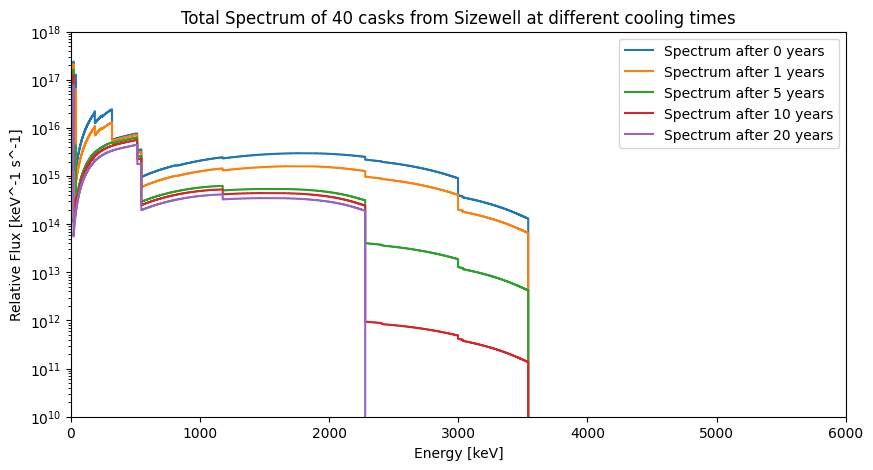

In [2]:
cask = Cask.from_reactor(
    "sizewell", total_mass=100000
)  # 100 tonnes = ten 10-tonne casks
cask_removal_times = [0.5, 5, 10, 20]
simulation_times = [0, 1, 5, 10, 20]

spectra = []
for simulation_time in simulation_times:
    new_ages = np.array(cask_removal_times) + simulation_time
    time_spectra = []
    for removal_time in new_ages:
        spec = cask.get_total_spectrum(removal_time=removal_time)
        time_spectra.append(spec)
    total_spec = time_spectra[0]
    for spec in time_spectra[1:]:
        total_spec = total_spec + spec
    spectra.append(total_spec)

# Plot the spectra
figure = plt.figure(figsize=(10, 5))
axes = figure.add_subplot(1, 1, 1)

for spec, simulation_time in zip(spectra, simulation_times, strict=True):
    axes.step(
        spec.energy[:-1],
        spec.flux,
        where="post",
        label=f"Spectrum after {simulation_time} years",
    )

axes.set_xlim(0, 6000)
axes.set_ylim(1e10, 1e18)
axes.set_xlabel("Energy [keV]")
axes.set_ylabel("Relative Flux [keV^-1 s^-1]")
axes.set_title(
    f"Total Spectrum of 40 casks from {reactor.capitalize()} at different cooling times"
)
axes.set_yscale("log")
axes.legend()

plt.show()